In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing the dataset
df = pd.read_csv('/Users/manurajgoel/Desktop/MLPRACTICAL/titanic/train.csv')

In [3]:
# Shape/size of the data
df.shape

(891, 12)

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# listing down all the columns
df.columns.values

# CATEGORICAL - Survived, Pclass, sex, Sibsp, Parch, Embarked
# NUMERICAL - Age, Fare, PassengerID
# MIXED -  Name, ticket, cabin

array(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype=object)

In [6]:
df.info()
# by this we get to know about the how and in which column are missing values present

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.isnull().sum()
# we get to know about how many missing values are present in each column


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
# Dropping CABIN column
# there are more than 70% missing values, so we'll drop

df.drop(columns = ['Cabin'], inplace=True)

In [9]:
# Filling missing values for EMBARKED(city)
'''
As there were only 2 missing values
so we first find out the no of each city
and we will fill it with the most appeared city
'''

df['Embarked'].value_counts()

# filling it with S
df['Embarked'] = df['Embarked'].fillna('S')

In [10]:
# now checking if we want to change 'SibSp' and 'Parch' into category or not

df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [11]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [12]:
# Changing data type for following columns:

df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

In [13]:
df.info()
# now we have filled all missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(4), float64(2), int64(3), object(2)
memory usage: 52.8+ KB


In [14]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


Out of 891 people 38% people survived in the accident
Out of 891 people 62% people died in the accident


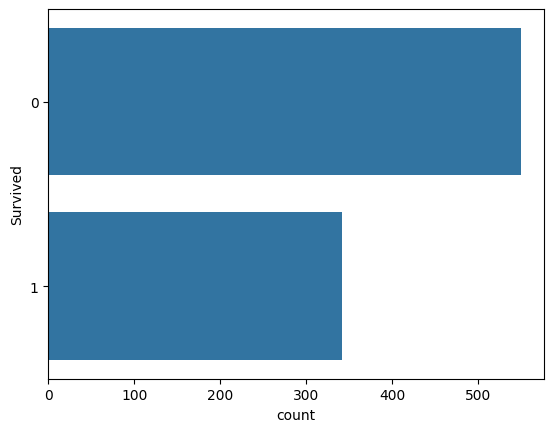

In [15]:
# UNIVARIATE ANALYSIS (one columns at a time)

# Survived column - to check % of person died and survived
sns.countplot(df['Survived'])

death_percent = round((df['Survived'].value_counts().values[0]/891)*100)
print(f"Out of 891 people {100 - death_percent}% people survived in the accident")
print(f"Out of 891 people {death_percent}% people died in the accident")

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: count, dtype: float64


<Axes: xlabel='count', ylabel='Pclass'>

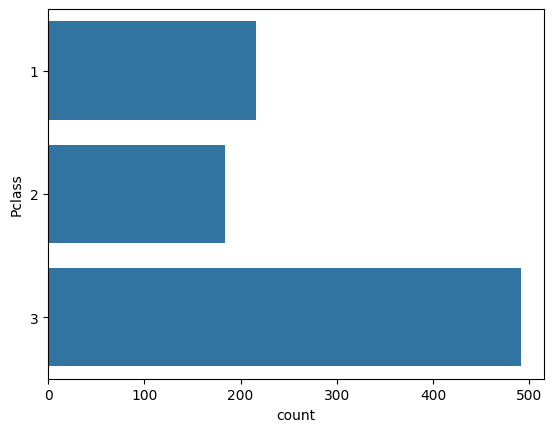

In [16]:
# Pclass column
'''
1 -> First class
2 -> Second class
3 -> Third class
'''

print((df['Pclass'].value_counts()/891)*100)
# this gives Percentage of passengers present in each class(1/2/3)

sns.countplot(df['Pclass'])

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64


<Axes: xlabel='count', ylabel='Sex'>

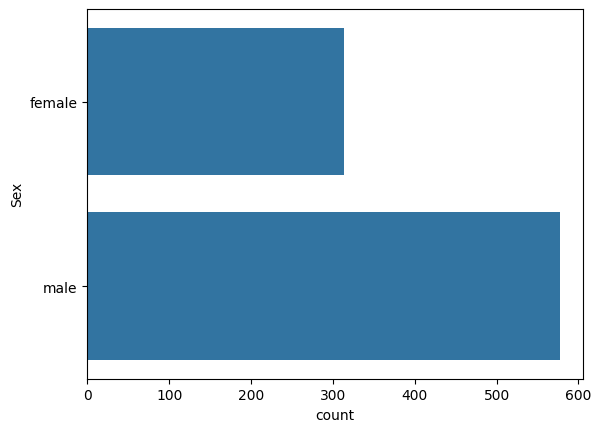

In [17]:
# Sex column
print((df['Sex'].value_counts()/891)*100)

sns.countplot(df['Sex'])

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


<Axes: ylabel='count'>

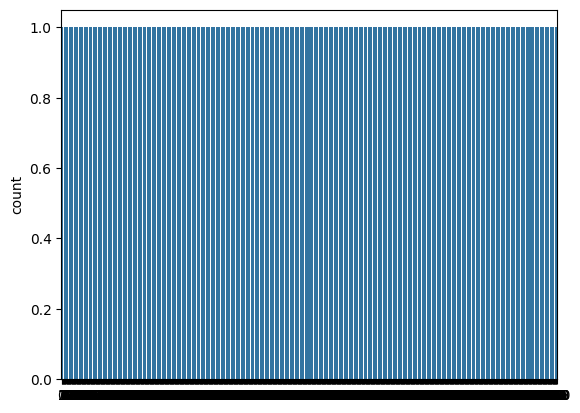

In [18]:
# SibSp column
# Number of siblings or spouses aboard the Titanic with the passenger.

print(df['SibSp'].value_counts())

sns.countplot(df['SibSp'])

Parch
0    76.094276
1    13.243547
2     8.978676
5     0.561167
3     0.561167
4     0.448934
6     0.112233
Name: count, dtype: float64


<Axes: ylabel='count'>

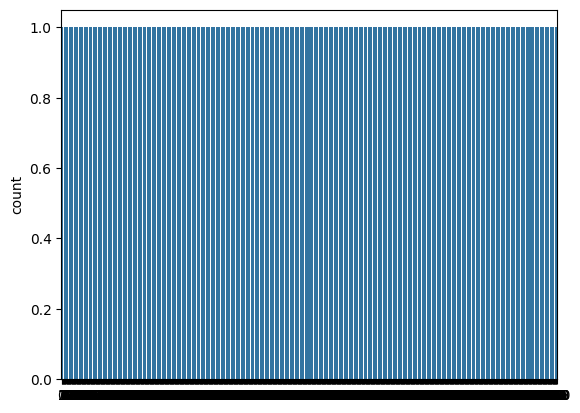

In [19]:
# Parch column
# Number of parents or children aboard with the passenger.

print((df['Parch'].value_counts()/891)*100)

sns.countplot(df['Parch'])

Embarked
S    72.502806
C    18.855219
Q     8.641975
Name: count, dtype: float64


<Axes: xlabel='count', ylabel='Embarked'>

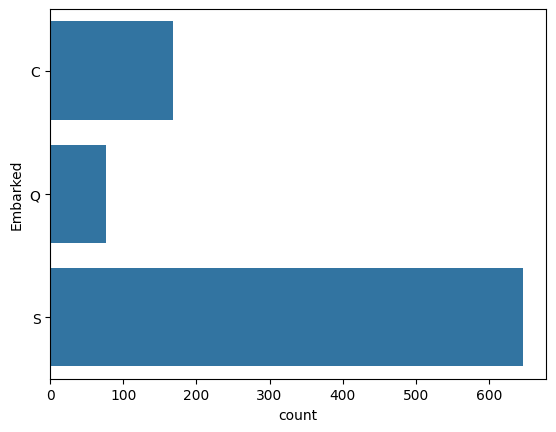

In [20]:
# Embarked column
# which city

print((df['Embarked'].value_counts()/891)*100)

sns.countplot(df['Embarked'])

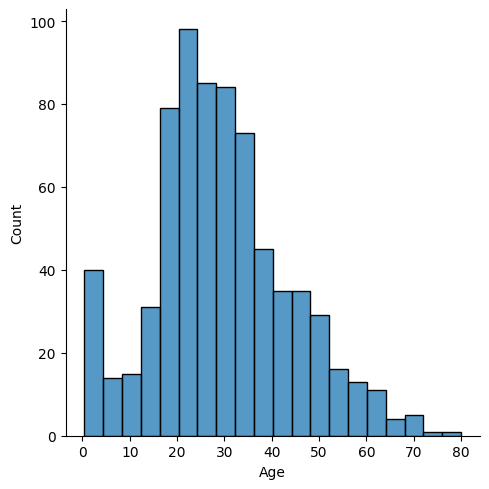

In [21]:
# AGE COLUMN

sns.displot(df['Age'])

<Axes: ylabel='Age'>

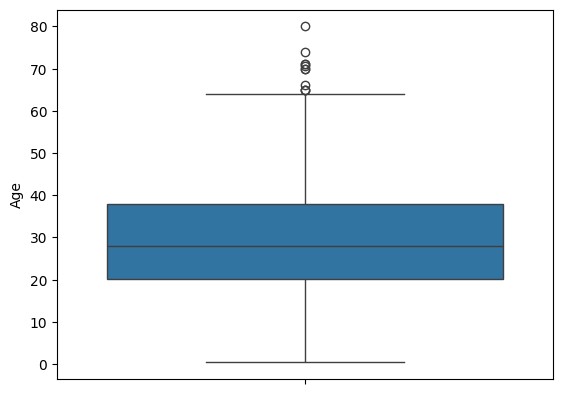

In [22]:
# To check outliers
sns.boxplot(df['Age'])

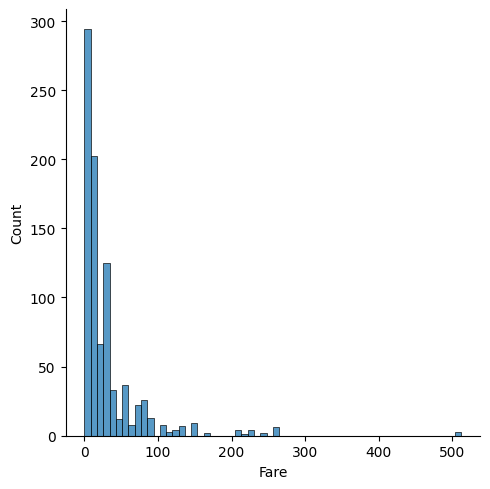

In [23]:
sns.displot(df['Fare'])

# highly skewed data
# outliers are present in data

Survived,0,1
Pclass,,
1,37.04,62.96
2,52.72,47.28
3,75.76,24.24


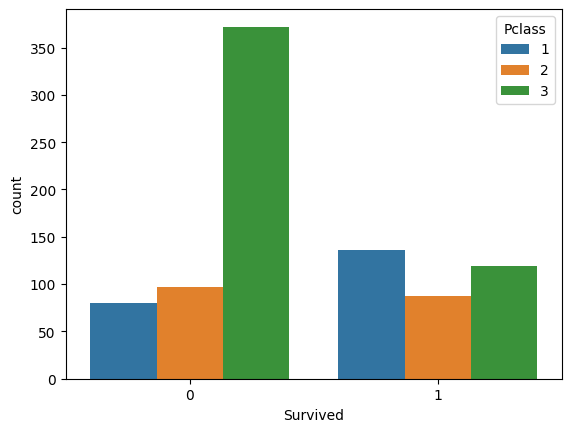

In [24]:
# MULTIVARIATE ANALYSIS
# SURVIVAL vs PCLASS

sns.countplot(x='Survived', hue='Pclass', data=df)

(pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100).round(2)


Survived,0,1
Sex,,
female,25.80,74.20
male,81.11,18.89


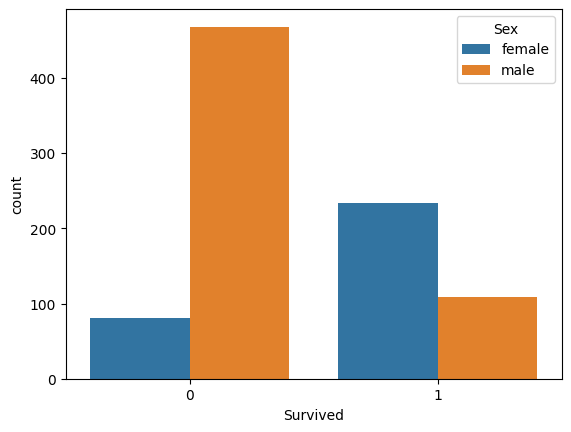

In [25]:
# SURVIVAL vs SEX

sns.countplot(x='Survived', hue='Sex', data=df)

(pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100).round(2)


Survived,0,1
Embarked,,
C,44.64,55.36
Q,61.04,38.96
S,66.10,33.90


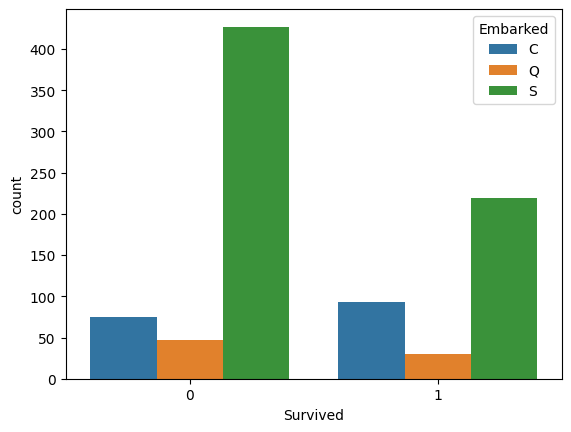

In [26]:
# SURVIVAL vs EMABARKED

sns.countplot(x='Survived', hue='Embarked', data=df)

(pd.crosstab(df['Embarked'], df['Survived'], normalize='index') * 100).round(2)


<Axes: xlabel='Age', ylabel='Count'>

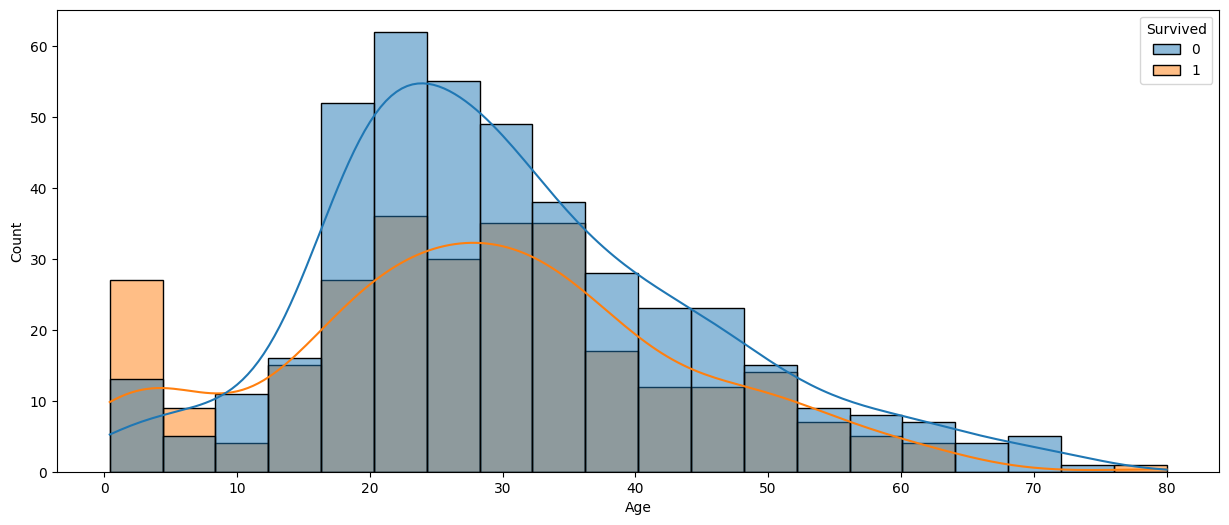

In [27]:
# SURVIVAL vs AGE

plt.figure(figsize=(15,6))

sns.histplot(data=df, x='Age', hue='Survived', kde=True)

<Axes: xlabel='Fare', ylabel='Count'>

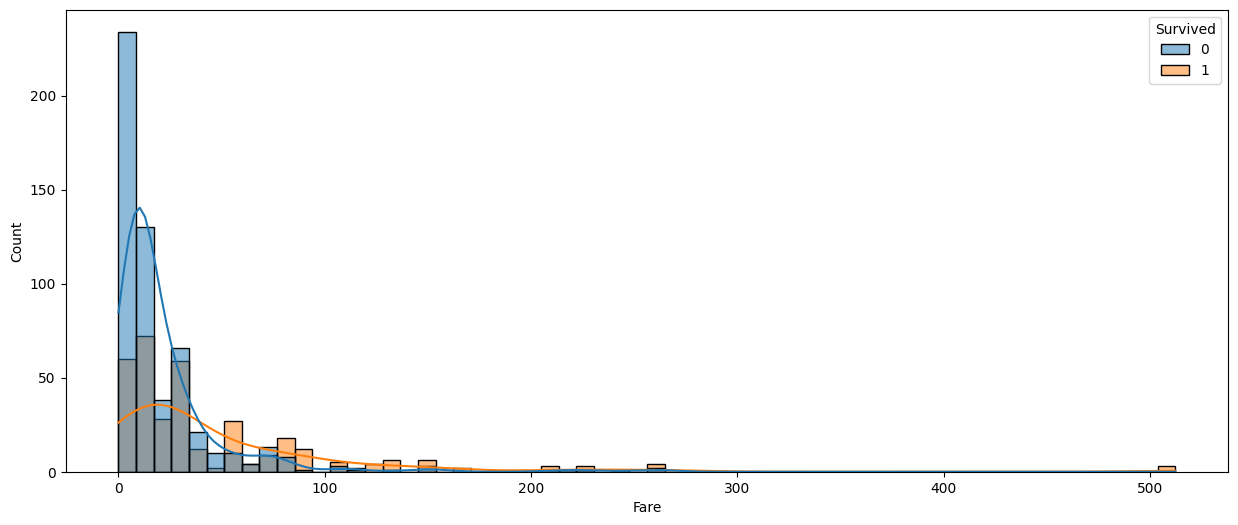

In [28]:
# SURVIVAL vs FARE

plt.figure(figsize=(15,6))

sns.histplot(data=df, x='Fare', hue='Survived', kde=True)

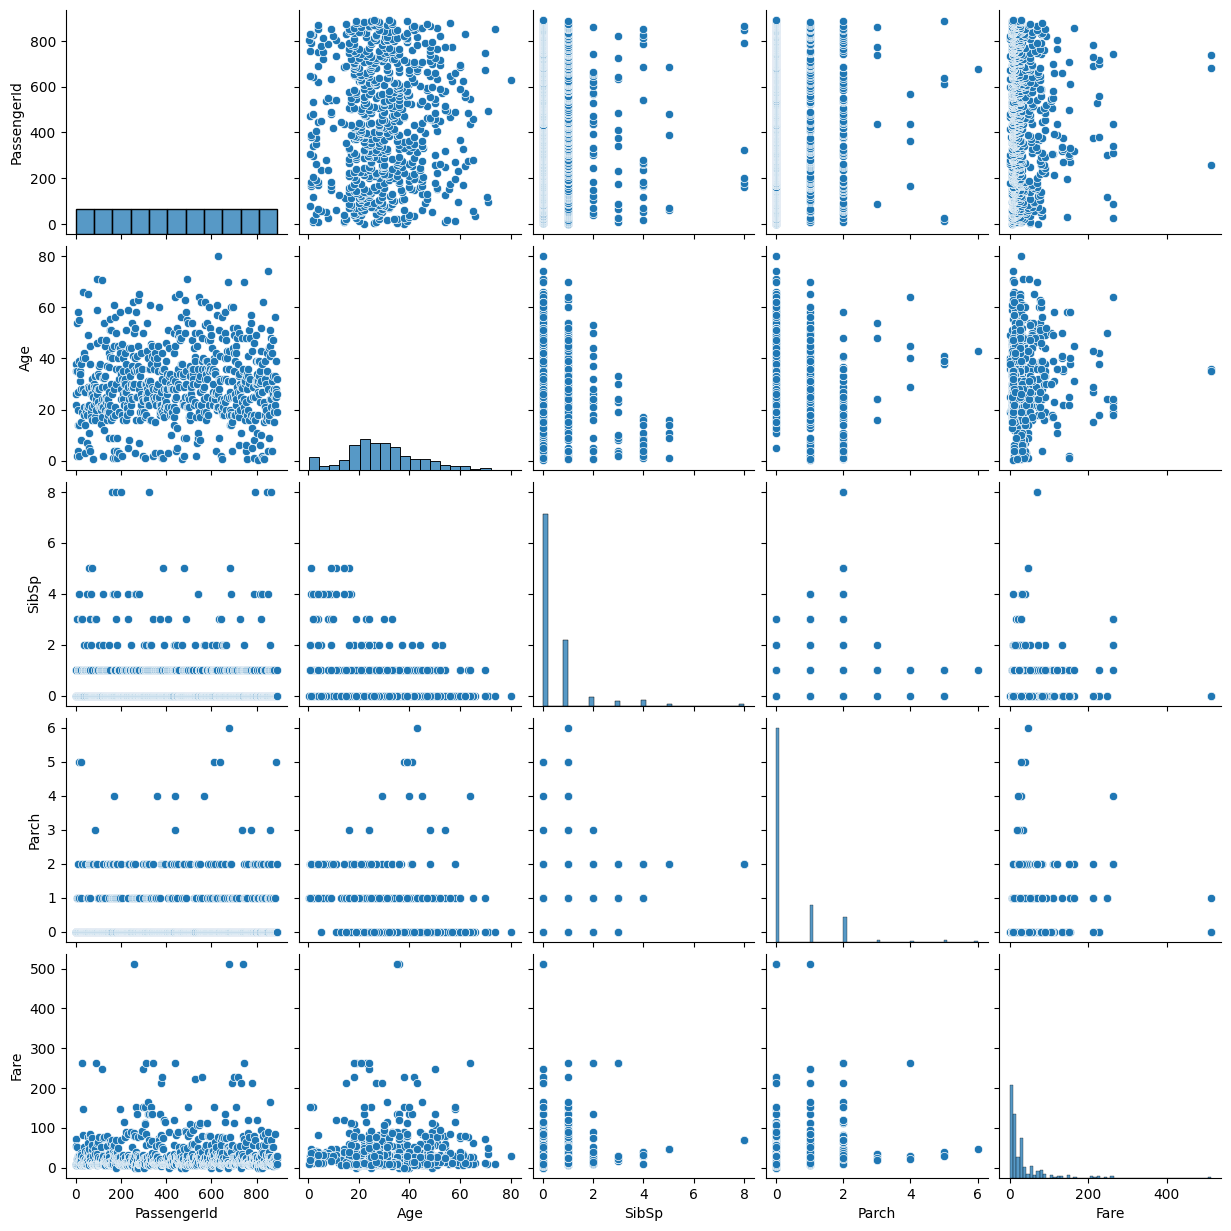

In [29]:
sns.pairplot(df)

<Axes: >

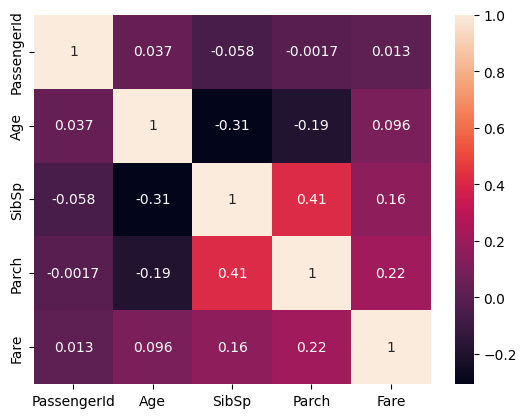

In [30]:
# HEATMAP (understanding feature relationships)
# For NUMERICAL column only

sns.heatmap(df.corr(numeric_only=True), annot=True)

In [31]:
# FEATURE ENGINEERING

# we'll create a new column i.e Family size = Parch + SibSp
df['Family_size'] = df['Parch'] + df['SibSp']

In [32]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_size
505,506,0,1,"Penasco y Castellana, Mr. Victor de Satode",male,18.0,1,0,PC 17758,108.9000,C,1
502,503,0,3,"O'Sullivan, Miss. Bridget Mary",female,NaN,0,0,330909,7.6292,Q,0
368,369,1,3,"Jermyn, Miss. Annie",female,NaN,0,0,14313,7.7500,Q,0
252,253,0,1,"Stead, Mr. William Thomas",male,62.0,0,0,113514,26.5500,S,0
292,293,0,2,"Levy, Mr. Rene Jacques",male,36.0,0,0,SC/Paris 2163,12.8750,C,0


In [33]:
# Now we will enginner a new feature by the name of family type

def family_type(number):
    if number==0:
        return "Alone"
    elif number>0 and number<=4:
        return 'Medium'
    else:
        return "Large"


In [34]:
df['family_type'] = df['Family_size'].apply(family_type)

In [35]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_size,family_type
217,218,0,2,"Jacobsohn, Mr. Sidney Samuel",male,42.0,1,0,243847,27.0000,S,1,Medium
126,127,0,3,"McMahon, Mr. Martin",male,NaN,0,0,370372,7.7500,Q,0,Alone
177,178,0,1,"Isham, Miss. Ann Elizabeth",female,50.0,0,0,PC 17595,28.7125,C,0,Alone
199,200,0,2,"Yrois, Miss. Henriette (""Mrs Harbeck"")",female,24.0,0,0,248747,13.0000,S,0,Alone
246,247,0,3,"Lindahl, Miss. Agda Thorilda Viktoria",female,25.0,0,0,347071,7.7750,S,0,Alone


In [36]:
# now we created a column Family_size
# so we can drop SibSp, Parch, Family_size

df.drop(columns = ['SibSp', 'Parch', 'Family_size'], inplace =True)

In [37]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,family_type
424,425,0,3,"Rosblom, Mr. Viktor Richard",male,18.0,370129,20.2125,S,Medium
314,315,0,2,"Hart, Mr. Benjamin",male,43.0,F.C.C. 13529,26.2500,S,Medium
653,654,1,3,"O'Leary, Miss. Hanora ""Norah""",female,NaN,330919,7.8292,Q,Alone
451,452,0,3,"Hagland, Mr. Ingvald Olai Olsen",male,NaN,65303,19.9667,S,Medium
256,257,1,1,"Thorne, Mrs. Gertrude Maybelle",female,NaN,PC 17585,79.2000,C,Alone


In [38]:
# SURVIVAL vs FAMILY TYPE

(pd.crosstab(df['family_type'], df['Survived'], normalize='index') * 100).round(2)

Survived,0,1
family_type,,
Alone,69.65,30.35
Large,85.11,14.89
Medium,43.97,56.03


In [39]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Ticket',
       'Fare', 'Embarked', 'family_type'],
      dtype='object')

In [40]:
# ONE HOT ENCODING
# converts categorical columns into numerical columns

df.sample(4)

# for showing 3 cols we only need 2 cols 
pd.get_dummies(data=df, columns = ['Pclass', 'Sex', 'Embarked', 'family_type'], drop_first=True, dtype=int)

,PassengerId,Survived,Name,Age,Ticket,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,family_type_Large,family_type_Medium
0,1,0,"Braund, Mr. Owen Harris",22.0,A/5 21171,7.2500,0,1,1,0,1,0,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,PC 17599,71.2833,0,0,0,0,0,0,1
2,3,1,"Heikkinen, Miss. Laina",26.0,STON/O2. 3101282,7.9250,0,1,0,0,1,0,0
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,113803,53.1000,0,0,0,0,1,0,1
4,5,0,"Allen, Mr. William Henry",35.0,373450,8.0500,0,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,"Montvila, Rev. Juozas",27.0,211536,13.0000,1,0,1,0,1,0,0
887,888,1,"Graham, Miss. Margaret Edith",19.0,112053,30.0000,0,0,0,0,1,0,0
888,889,0,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,W./C. 6607,23.4500,0,1,0,0,1,0,1
889,890,1,"Behr, Mr. Karl Howell",26.0,111369,30.0000,0,0,1,0,0,0,0


In [41]:
df = pd.get_dummies(
    data=df,
    columns=['Pclass','Sex','Embarked','family_type'],
    drop_first=True,
    dtype=int
)

In [42]:
# BULIDING MODEL

In [43]:
df = df.drop(columns=['Ticket', 'Name'])

In [44]:
# Separating features and target
X = df.drop(columns = 'Survived')
y = df['Survived']

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
age_mean = X_train['Age'].mean()
age_std = X_train['Age'].std()

age_low = age_mean - 3 * age_std
age_high = age_mean + 3 * age_std

In [47]:
mask_train_age = (X_train['Age'] >= age_low) & (X_train['Age'] <= age_high)

X_train = X_train[mask_train_age]
y_train = y_train[mask_train_age]

X_test['Age'] = X_test['Age'].clip(lower=age_low, upper=age_high)

In [48]:
Q1 = X_train['Fare'].quantile(0.25)
Q3 = X_train['Fare'].quantile(0.75)

iqr = Q3 - Q1

fare_low = Q1 - 1.5 * iqr
fare_high = Q3 + 1.5 * iqr
 
# Remove outlier rows from training set
mask_train_fare = (X_train['Fare'] > fare_low) & (X_train['Fare'] < fare_high)

X_train = X_train[mask_train_fare]
y_train = y_train[mask_train_fare]

In [49]:
# Clip test set to same bounds
X_test['Fare'] = X_test['Fare'].clip(lower=fare_low, upper=fare_high)
 
print(f"Training set size after outlier removal: {X_train.shape}")
print(f"Test set size (unchanged): {X_test.shape}")
 

Training set size after outlier removal: (493, 10)
Test set size (unchanged): (179, 10)


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [52]:
# Predict
X_train = pd.DataFrame(X_train).fillna(0)
X_test = pd.DataFrame(X_test).fillna(0)

y_pred = model.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8044692737430168
[[89 16]
 [19 55]]
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [56]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.8045
Decision Tree: 0.7430
Random Forest: 0.8268
Gradient Boosting: 0.8156
SVM: 0.8156
KNN: 0.8212
Naive Bayes: 0.7207
